# Foundation Shade Recommender: Interactive Demo

This notebook follows one clear path from a selfie to a ranked list of
foundation colours. It is the best starting point for readers.

**Method:** MediaPipe landmarks → cheek/forehead pixels → median RGB →
CIELAB → CIEDE2000 product ranking.

The result is a colour-similarity prototype, not a purchasing guarantee.
Lighting, camera processing, makeup, and catalogue colour quality all
affect the result.


## 1. Setup



In [1]:
from pathlib import Path
import os
import subprocess
import sys


def find_project_root(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return None


project_root = find_project_root(Path.cwd())

if project_root is None:
    raise FileNotFoundError(
        "Run this notebook from inside the project folder."
    )

os.chdir(project_root)

# Connect the local `foundation_matcher` package (src/ layout) so the
# imports below resolve even if the editable install has not been run.
src_path = project_root / "src"
if src_path.is_dir() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Install the package and its dependencies. Non-fatal: if a dependency
# wheel is unavailable the local package is still importable via src_path.
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-e", "."],
    check=False,
)
if result.returncode != 0:
    print("Warning: `pip install -e .` failed; using src/ on sys.path instead.")

import importlib.util

if importlib.util.find_spec("foundation_matcher") is None:
    raise ModuleNotFoundError(
        f"foundation_matcher not found. Expected package at {src_path}."
    )

print("Project root:", project_root)
print("foundation_matcher connected from:", src_path)

Project root: /Users/mafteevaalina/Downloads/capstone/Predictive-beauty-analysis-using-computer-vision-and-machine-learning-
foundation_matcher connected from: /Users/mafteevaalina/Downloads/capstone/Predictive-beauty-analysis-using-computer-vision-and-machine-learning-/src


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from foundation_matcher.config import (
    FACE_LANDMARKER_URL,
    FOUNDATION_DATA_URL,
    LUXXIFY_PRODUCT_URL,
)
from foundation_matcher.data import (
    apply_manual_prices,
    attach_price_estimates,
    load_foundation_catalog,
    summarize_catalog_quality,
)
from foundation_matcher.face import (
    create_face_landmarker,
    download_face_landmarker,
    extract_skin_tone,
)
from foundation_matcher.recommender import recommend_foundations
from foundation_matcher.visualization import (
    plot_brand_coverage,
    plot_catalog_lab,
    plot_lab_distributions,
    plot_match_swatches,
    plot_price_distribution,
    plot_skin_previews,
)


## 2. Prepare the foundation catalogue

The source catalogue stores digital HEX colours. The project cleans those
values and converts them to CIELAB, where numerical distance is more
closely related to perceived colour difference than ordinary RGB distance.


In [3]:
try:
    products = load_foundation_catalog()
except Exception as error:
    print(
        "Could not download the foundation catalogue from "
        f"{FOUNDATION_DATA_URL}.\n"
        "Check your internet connection and that the URL is still reachable, "
        "then re-run this cell."
    )
    raise

# Price isn't part of the source catalogue. Attach a brand-level estimate
# from a separate product export, matched by normalized brand name since
# the two datasets share no product-level ID. This is best-effort: niche
# and international brands the price reference doesn't carry get price =
# NaN rather than a guess, which recommend_foundations displays as
# "Unknown" further down instead of dropping the row.
try:
    price_reference = pd.read_csv(LUXXIFY_PRODUCT_URL, low_memory=False)
    products = attach_price_estimates(products, price_reference)
    price_coverage = products["price"].notna().mean()
    print(f"Price coverage: {price_coverage:.1%} of catalogue rows")
except Exception as error:
    print(
        f"Could not attach price estimates from {LUXXIFY_PRODUCT_URL} "
        f"({error}); continuing without price information."
    )

print(f"Catalogue rows: {len(products):,}")
print(f"Brands: {products['brand'].nunique():,}")
print(f"Unique HEX colours: {products['hex'].nunique():,}")

display(
    products[
        ["brand", "product", "hex", "lab_L", "lab_a", "lab_b"]
    ].head()
)


Price coverage: 58.6% of catalogue rows
Catalogue rows: 625
Brands: 36
Unique HEX colours: 617


,brand,product,hex,lab_L,lab_a,lab_b
0,Maybelline,Fit Me,F3CFB3,85.472362,8.517204,18.616685
1,Maybelline,Fit Me,FFE3C2,91.727724,4.665555,19.653829
2,Maybelline,Fit Me,FFE0CD,91.225835,7.759517,13.226062
3,Maybelline,Fit Me,FFD3BE,87.760784,12.374977,16.190198
4,Maybelline,Fit Me,BD9584,64.947764,12.511680,14.708033


### Fill in missing prices by hand

The external price reference only covers mainstream brands, so 24 brands
show "Unknown" further down. The dict below is pre-filled with **rough
ballpark USD prices** from public listings (converted from local currency
where the brand sells mainly in INR / NGN / JPY) — treat these as
estimates, not verified retail prices, and adjust any you know better. Set
a value to `None` to send that brand back to "Unknown". Nothing here
overwrites a price that was already found from the reference.


In [4]:
# Approximate USD retail prices for brands the external reference doesn't
# carry (ballpark figures from public listings, converted to USD where the
# brand sells mainly in INR / NGN / JPY). These are rough per-brand
# estimates, not live-verified prices — adjust any you know better. Leave a
# value as None to keep that brand showing "Unknown".
MANUAL_BRAND_PRICES = {
    "Make Up For Ever": 43.0,   # 40 shades - HD Skin, ~$43 at Sephora
    "Beauty Bakerie": 32.0,     # 30 shades - InstaBake Aqua Glass
    "Black Up": 44.0,           # 18 shades - French, deeper-tone range
    "Laws of Nature": 25.0,     # 17 shades - US indie natural brand
    "Addiction": 48.0,          # 17 shades - Addiction Tokyo, prestige
    "Trim & Prissy": 12.0,      # 13 shades - Nigerian brand
    "Black Opal": 11.0,         # 12 shades - US mass, skin-of-color line
    "House of Tara": 15.0,      # 11 shades - Nigerian brand
    "Elsas Pro": 12.0,          # 11 shades - Indian pro makeup line
    "Shu Uemera": 52.0,         # 11 shades - Japanese luxury
    "Hegai and Ester": None,    # 10 shades - no reliable public price found
    "RMK": 40.0,                # 9 shades - Japanese
    "Iman": 20.0,               # 8 shades - US, skin-of-color line
    "Bharat & Doris": 8.0,      # 7 shades - Indian pro/budget
    "Shiseido": 50.0,           # 6 shades - Synchro Skin, ~$48-50
    "Kate": 20.0,               # 6 shades - Kanebo, Japanese drugstore
    "IPSA": 45.0,               # 6 shades - Japanese, Shiseido-owned
    "Kuddy": 8.0,               # 5 shades - Nigerian brand
    "Nykaa": 9.0,               # 5 shades - Indian (~Rs 500-800)
    "Lakmé": 6.0,               # 4 shades - 9-to-5 line (~Rs 349-650)
    "Olivia": 4.0,              # 4 shades - Indian budget brand
    "Lotus Herbals": 8.0,       # 4 shades - Indian
    "Colorbar": 12.0,           # 3 shades - Indian (~Rs 950-1065)
    "Blue Heaven": 3.0,         # 2 shades - Indian ultra-budget
}

# For a single specific product rather than a whole brand, add entries like
#   MANUAL_PRODUCT_PRICES = {("Lakmé", "9 to 5"): 8.0}
MANUAL_PRODUCT_PRICES: dict[tuple[str, str], float] = {}

if "price" in products.columns:
    products = apply_manual_prices(
        products,
        MANUAL_BRAND_PRICES,
        product_prices=MANUAL_PRODUCT_PRICES,
    )
    coverage = products["price"].notna().mean()
    print(f"Price coverage after manual fills: {coverage:.1%} of catalogue rows")
else:
    print("No price column to fill (price attachment failed earlier).")


Price coverage after manual fills: 98.4% of catalogue rows


,lab_L,lab_a,lab_b
count,625.00,625.00,625.00
mean,65.58,14.45,26.94
std,17.53,5.93,8.15
min,10.51,-1.69,5.94
25%,54.67,10.32,21.12
50%,70.27,14.15,26.74
75%,78.81,18.01,32.58
max,94.52,39.96,54.50


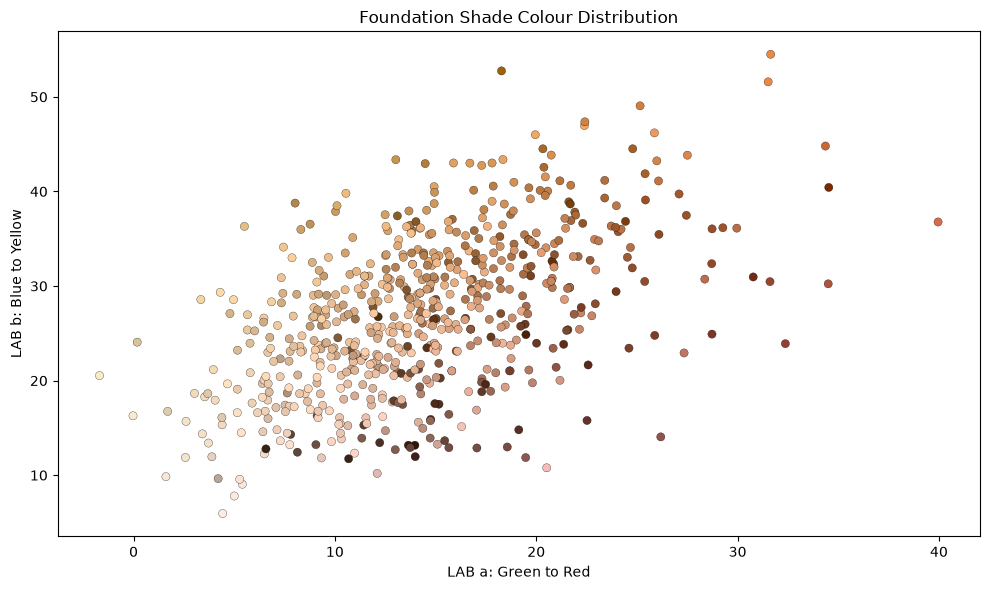

In [5]:
display(products[["lab_L", "lab_a", "lab_b"]].describe().round(2))
plot_catalog_lab(products)
plt.show()


## 2b. Exploratory data analysis

The scatter plot above shows *where* the catalogue's colours sit; it
doesn't show whether that coverage is actually usable. This section looks
at data-quality signals a row/brand count alone hides: brands too thin to
offer real choice, exact colour duplicates, the lightness range actually
covered, and how much of the catalogue has price data.


In [6]:
quality_summary = summarize_catalog_quality(products)
display(pd.Series(quality_summary, name="value").to_frame())


,value
total_rows,625.000
total_brands,36.000
brands_with_fewer_than_5_shades,5.000
duplicate_hex_rows,8.000
lab_L_min,10.510
lab_L_max,94.520
price_coverage,0.984


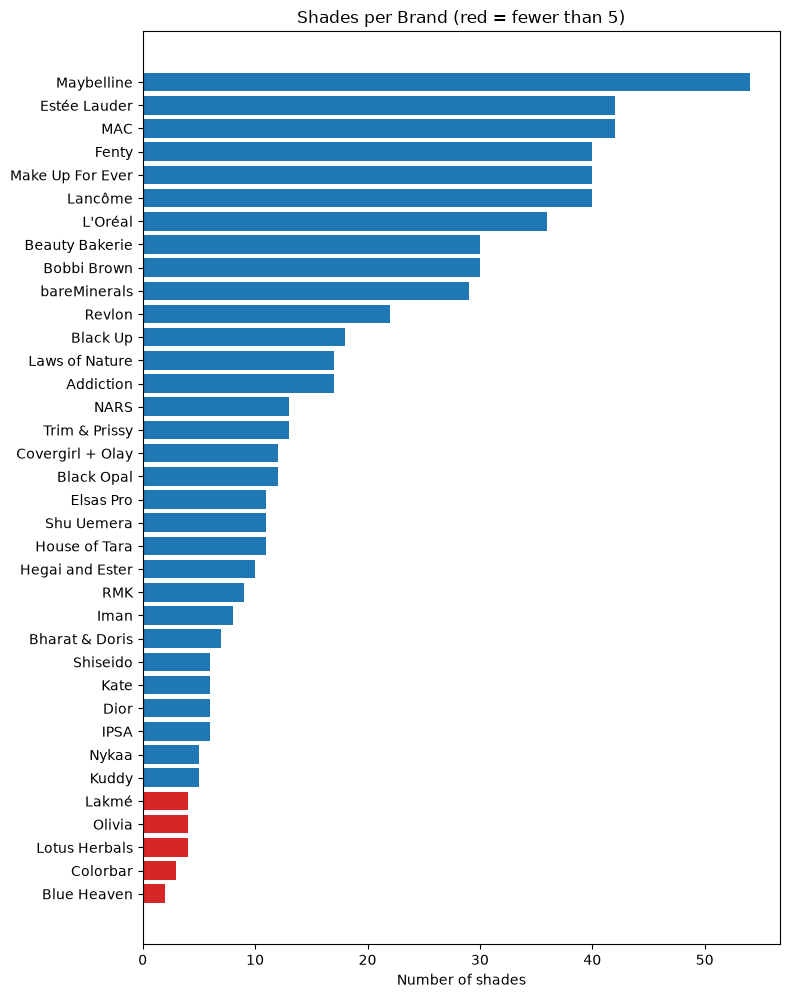

In [7]:
plot_brand_coverage(products)
plt.show()


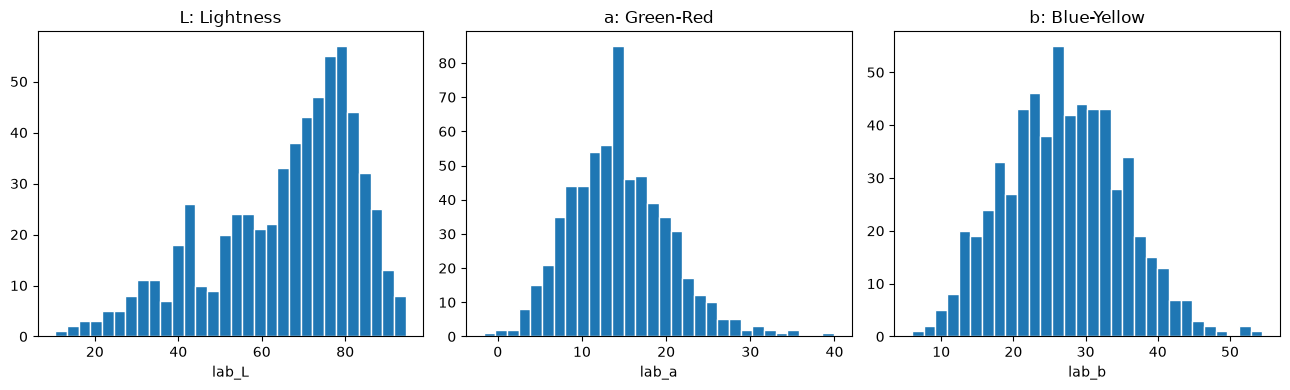

In [8]:
plot_lab_distributions(products)
plt.show()


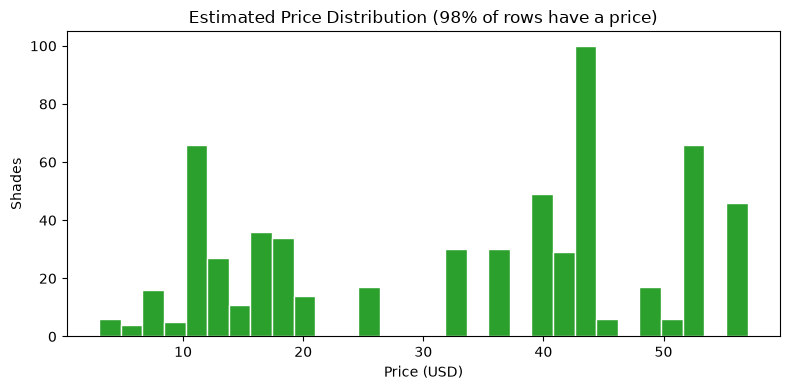

In [9]:
if "price" in products.columns:
    plot_price_distribution(products)
    plt.show()
else:
    print("No price column available (price attachment failed earlier).")


**Reading these results:** a handful of brands have too few shades to
offer a meaningfully different match at that brand (the red bars above);
a few catalogue rows are exact colour duplicates, which add nothing to
CIEDE2000 ranking beyond noise; and price coverage is well under 100%, so
some recommendations below will show "Unknown" rather than a guessed
price. None of this is a bug — it's a property of the underlying public
catalogue — but it's worth knowing before trusting any single
recommendation as authoritative. It also has no undertone (warm/cool/
neutral) field at all: the LAB `a`/`b` scatter above captures some of that
signal, but not as an explicit, checkable label.


## 3. Select one or more selfies

For a better estimate, use unfiltered, front-facing images taken in
even natural light. Avoid dramatic shadows and coloured lighting.

You can process several images at once — useful for comparing the same
person under different lighting, or comparing different people. Section 4
detects and previews every image; section 5 ranks foundations for one
chosen image (`PRIMARY_IMAGE_INDEX` below).

The images remain in the current runtime unless you explicitly save them.
Do not commit personal images to GitHub.


In [10]:
try:
    model_path = download_face_landmarker("models/face_landmarker.task")
except Exception as error:
    print(
        "Could not download the MediaPipe face landmarker model from "
        f"{FACE_LANDMARKER_URL}.\n"
        "Check your internet connection and that the URL is still reachable, "
        "then re-run this cell."
    )
    raise

# Add or remove paths here to select which local images to process. To use
# your own selfie: save/copy the image file anywhere on disk (e.g. into
# data/) and add its path below.
image_paths = [
    Path("data/example_selfie.jpg"),
    Path("data/example_selfie_2.jpg"),
    Path("data/example_selfie_3.jpg"),
    Path("data/example_selfie_4.jpg"),
    Path("data/example_selfie_5.jpg"),
    Path("data/example_selfie_6.jpg"),
    Path("data/example_selfie_7.jpg"),
    Path("data/example_selfie_8.jpg"),
    Path("data/example_selfie_9.jpg"),
    Path("data/example_selfie_10.jpg"),
]
missing_paths = [str(path) for path in image_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        f"Image(s) not found: {missing_paths}. Set image_paths to local "
        "selfies before running this cell."
    )

print(f"Selected {len(image_paths)} image(s):")
for path in image_paths:
    print(" -", path)


Selected 10 image(s):
 - data/example_selfie.jpg
 - data/example_selfie_2.jpg
 - data/example_selfie_3.jpg
 - data/example_selfie_4.jpg
 - data/example_selfie_5.jpg
 - data/example_selfie_6.jpg
 - data/example_selfie_7.jpg
 - data/example_selfie_8.jpg
 - data/example_selfie_9.jpg
 - data/example_selfie_10.jpg


## 4. Detect facial regions and estimate skin colour

The green circles show the sampled regions: both cheeks and the centre
forehead. The estimator trims the darkest and brightest 5% of sampled
pixels and uses the median of the remainder.

Each image is processed independently; a photo that fails detection is
skipped with a warning instead of stopping the whole batch. Every
successfully processed image gets its own row in the preview grid below.


W0000 00:00:1790067607.101558 2224134 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1790067607.211997 2224134 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 88), renderer: Apple M2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1790067607.217728 2224135 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790067607.227817 2224142 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


data/example_selfie.jpg -> RGB [157, 115, 96], LAB [52.15, 13.94, 17.01]


data/example_selfie_2.jpg -> RGB [184, 151, 149], LAB [65.35, 11.97, 5.69]


data/example_selfie_3.jpg -> RGB [98, 64, 55], LAB [30.74, 13.59, 11.55]


data/example_selfie_4.jpg -> RGB [160, 135, 121], LAB [58.21, 7.23, 11.06]


data/example_selfie_5.jpg -> RGB [211, 174, 152], LAB [73.8, 10.19, 16.35]
data/example_selfie_6.jpg -> RGB [221, 203, 191], LAB [82.83, 4.29, 8.25]


data/example_selfie_7.jpg -> RGB [243, 220, 198], LAB [89.07, 4.46, 13.69]
data/example_selfie_8.jpg -> RGB [254, 207, 194], LAB [86.8, 14.64, 12.71]


data/example_selfie_9.jpg -> RGB [114, 82, 69], LAB [37.92, 11.49, 12.9]


data/example_selfie_10.jpg -> RGB [159, 119, 110], LAB [53.7, 14.33, 11.05]


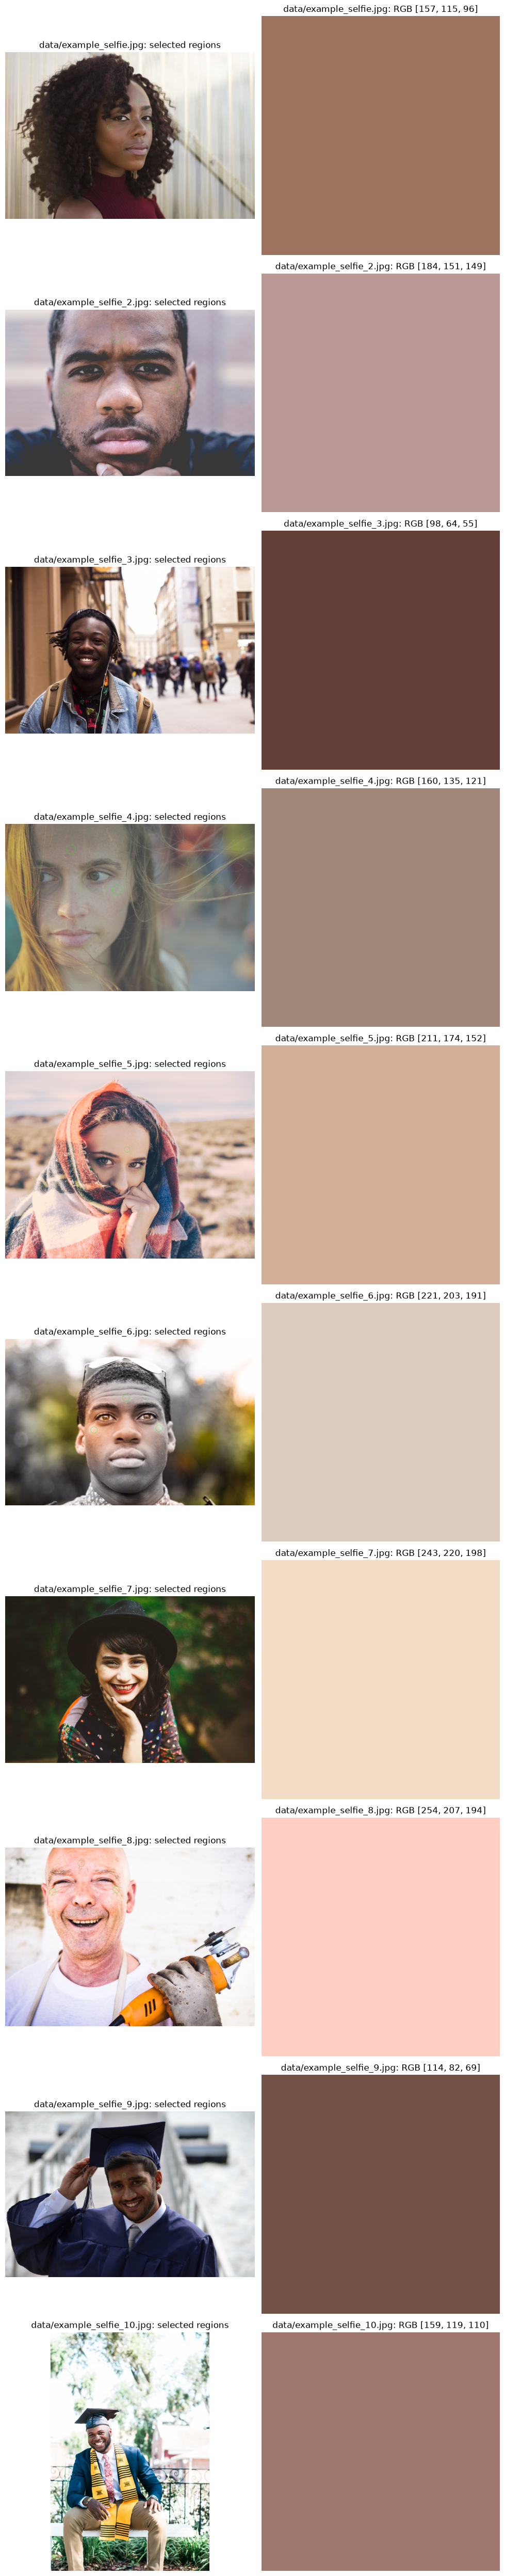

In [11]:
landmarker = create_face_landmarker(model_path)
skin_tones = []
processed_labels = []
try:
    for path in image_paths:
        try:
            skin_tone = extract_skin_tone(path, landmarker)
        except ValueError as error:
            print(
                f"Skipping {path}: {error}\n"
                "Try a well-lit, front-facing photo where the forehead and "
                "both cheeks are visible and not covered by hair, glasses, "
                "or shadow.\n"
            )
            continue

        if skin_tone.face_count > 1:
            print(
                f"Warning: {skin_tone.face_count} faces were detected in "
                f"{path}. The estimate uses only the first face MediaPipe "
                "returned; use a photo with a single face for a reliable "
                "match."
            )

        print(
            f"{path} -> RGB {skin_tone.rgb.tolist()}, "
            f"LAB {skin_tone.lab.round(2).tolist()}"
        )
        skin_tones.append(skin_tone)
        processed_labels.append(str(path))
finally:
    landmarker.close()

if not skin_tones:
    raise ValueError(
        "No image produced a usable skin-tone estimate. Add at least one "
        "well-lit, front-facing photo to image_paths and re-run."
    )

plot_skin_previews(skin_tones, processed_labels)
plt.show()


## 5. Rank foundation colours

CIEDE2000 compares each extracted LAB colour with every catalogue colour.
Smaller Delta E values indicate closer perceptual similarity. Every
successfully processed image from section 4 gets its own ranking and
swatch comparison below.



=== data/example_selfie.jpg ===


,brand,product,hex,price,color_distance
0,Revlon,ColorStay,A7745E,$18,2.71
1,Maybelline,Fit Me,9D7359,$11,2.84
2,Make Up For Ever,Ultra HD,996754,$43,4.50
3,Elsas Pro,Full Coverage,906656,$12,5.19
4,Laws of Nature,Foxy Finish,A37452,$25,5.32


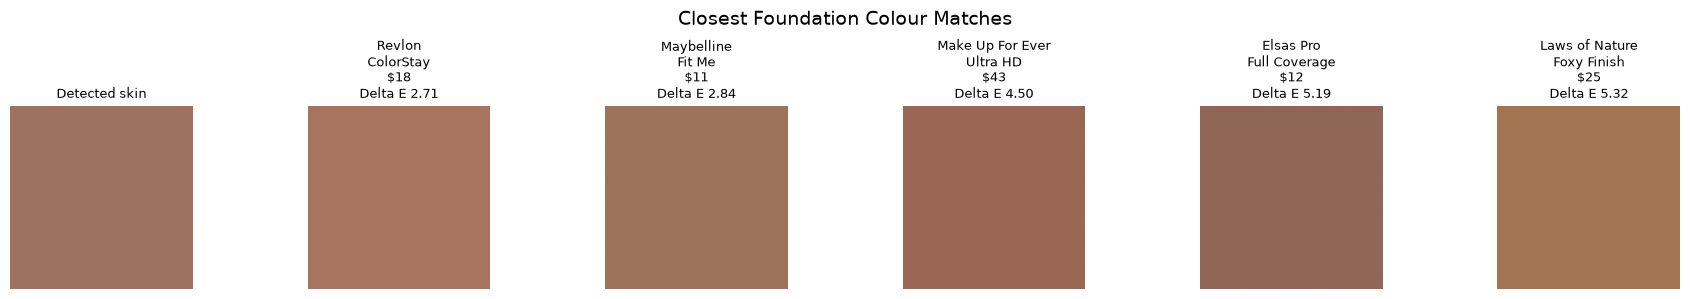


=== data/example_selfie_2.jpg ===


,brand,product,hex,price,color_distance
0,Maybelline,Fit Me,BD9584,$11,6.55
1,Laws of Nature,Foxy Finish,BB8F7F,$25,6.66
2,L'Oréal,Infalliable,D1A396,$17,6.88
3,Make Up For Ever,Ultra HD,DCA795,$43,9.60
4,Lotus Herbals,Make-Up Ecostay,B7A597,$8,9.82


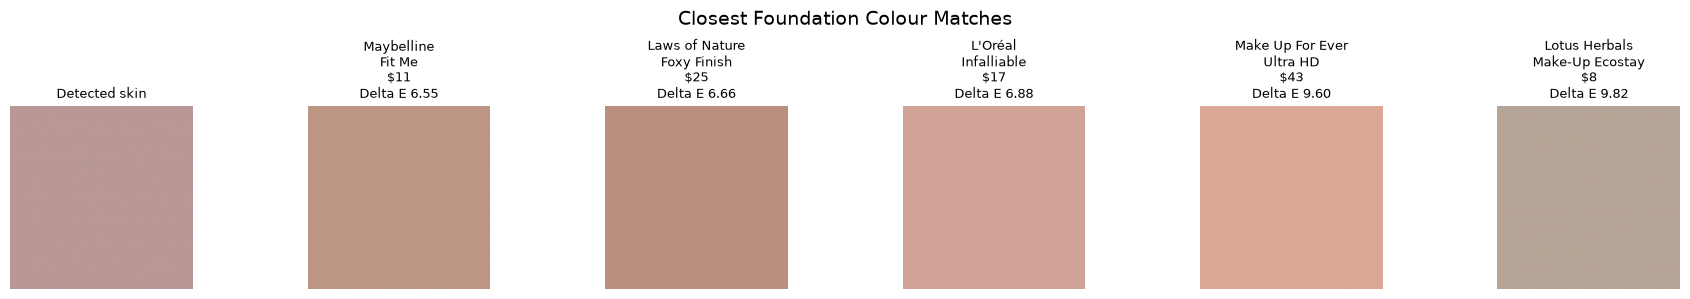


=== data/example_selfie_3.jpg ===


,brand,product,hex,price,color_distance
0,Make Up For Ever,Ultra HD,644136,$43,1.03
1,Black Opal,True Color,6A4338,$11,2.20
2,Elsas Pro,Full Coverage,734B41,$12,4.58
3,Beauty Bakerie,#1 CAKE MIX,623F2C,$32,4.66
4,Bobbi Brown,Skin Long-Wear,623726,$36,4.94


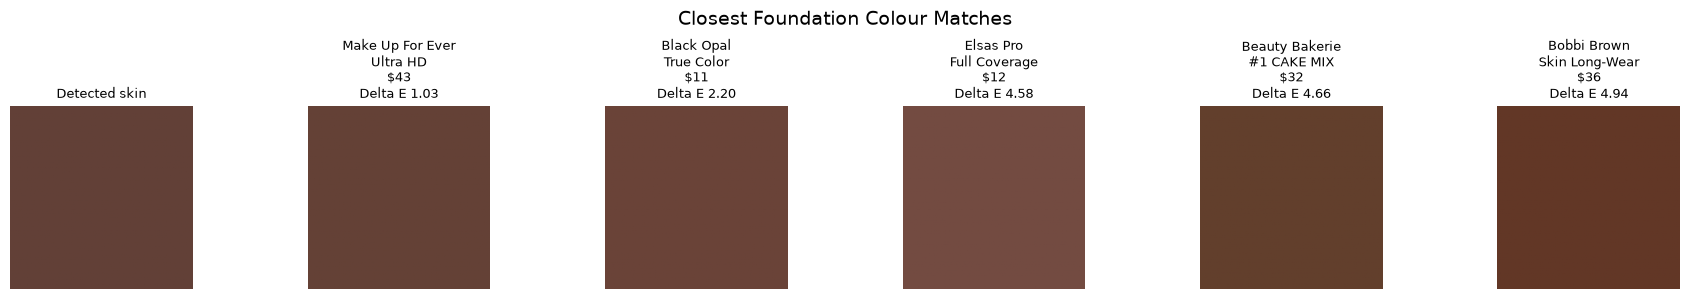


=== data/example_selfie_4.jpg ===


,brand,product,hex,price,color_distance
0,Laws of Nature,Foxy Finish,B19277,$25,6.30
1,Maybelline,Fit Me,B2856F,$11,6.41
2,Make Up For Ever,Ultra HD,B68069,$43,8.56
3,Revlon,ColorStay,BA8568,$18,8.72
4,bareMinerals,barePRO,AD7D59,$42,9.11


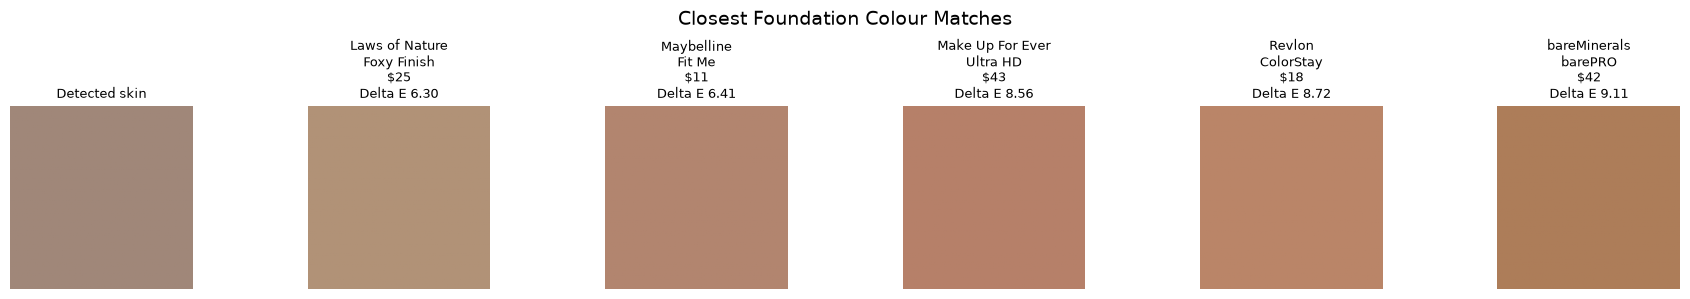


=== data/example_selfie_5.jpg ===


,brand,product,hex,price,color_distance
0,Nykaa,SKINgenius,D4AC93,$9,1.24
1,L'Oréal,True Match,DCB29A,$17,1.94
2,Make Up For Ever,Ultra HD,DCB59C,$43,2.20
3,Maybelline,Fit Me Matte,DCB297,$11,2.27
4,Laws of Nature,Foxy Finish,DEB399,$25,2.44


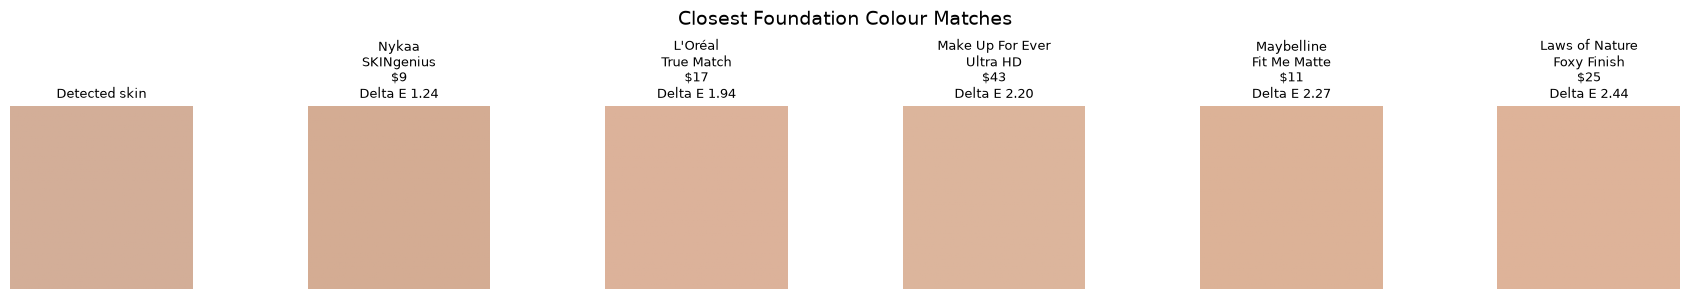


=== data/example_selfie_6.jpg ===


,brand,product,hex,price,color_distance
0,MAC,Studio Fix,E5D1BE,$44,3.20
1,L'Oréal,True Match,E7CBB5,$17,4.42
2,Maybelline,Fit Me,EDCFB9,$11,4.96
3,Covergirl + Olay,Simply Ageless,F7DCCA,$18,5.42
4,Make Up For Ever,Ultra HD,F9E3D5,$43,5.81


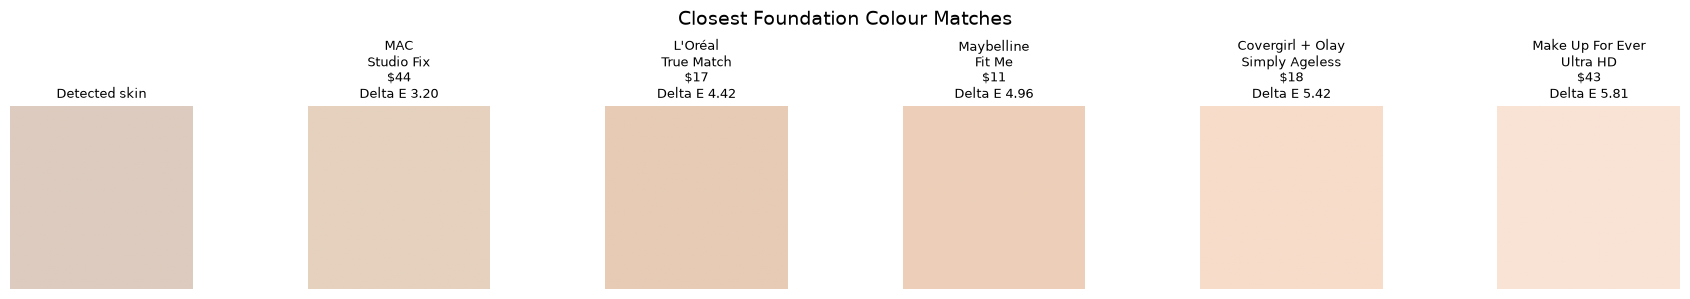


=== data/example_selfie_7.jpg ===


,brand,product,hex,price,color_distance
0,Beauty Bakerie,#1 CAKE MIX,F4DFC9,$32,1.03
1,Bobbi Brown,Skin Long-Wear,F5E0C8,$36,1.62
2,Fenty,PRO FILT'R,FDE3CC,$40,1.96
3,Covergirl + Olay,Simply Ageless,F7DCCA,$18,2.86
4,MAC,Studio Fix,E5D1BE,$44,2.89


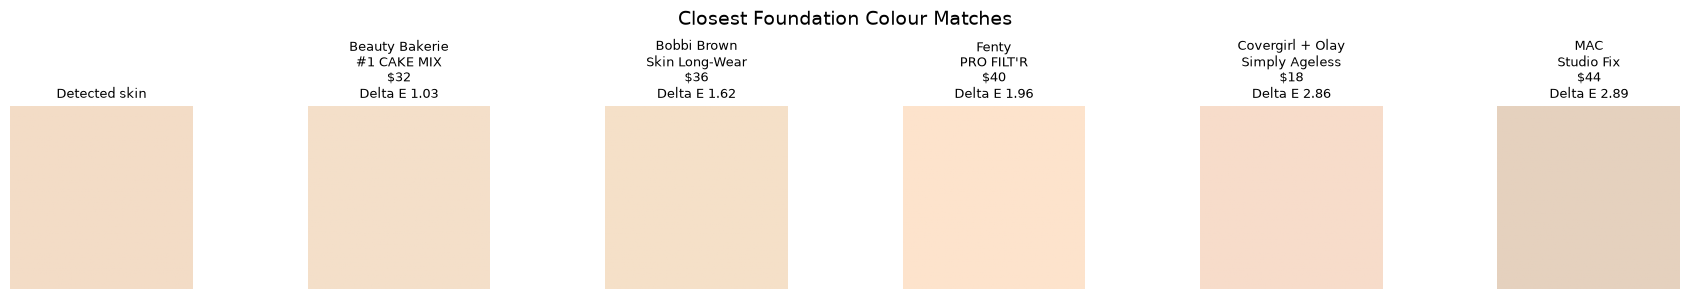


=== data/example_selfie_8.jpg ===


,brand,product,hex,price,color_distance
0,Make Up For Ever,Ultra HD,F7C3B3,$43,3.00
1,L'Oréal,Infalliable,FCD6C7,$17,3.18
2,Maybelline,Fit Me,FFD3BE,$11,3.71
3,L'Oréal,True Match,F0CBB9,$17,4.43
4,Maybelline,Fit Me Matte,F7D1BC,$11,4.96


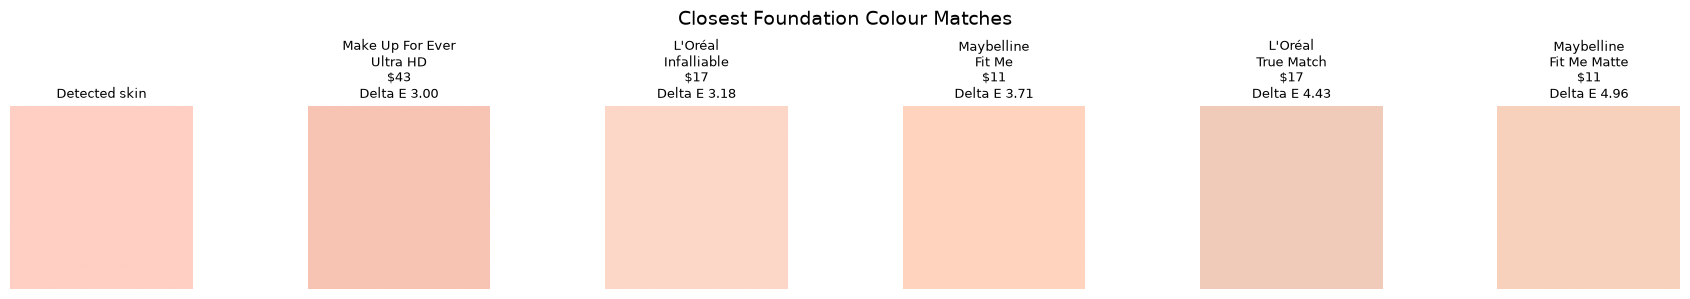


=== data/example_selfie_9.jpg ===


,brand,product,hex,price,color_distance
0,Maybelline,Fit Me,6B5041,$11,2.72
1,Trim & Prissy,Hi - Def,795340,$12,2.94
2,Elsas Pro,Full Coverage,734B41,$12,3.76
3,Black Opal,True Color,7A523A,$11,4.70
4,MAC,Studio Fix,724A32,$44,5.29


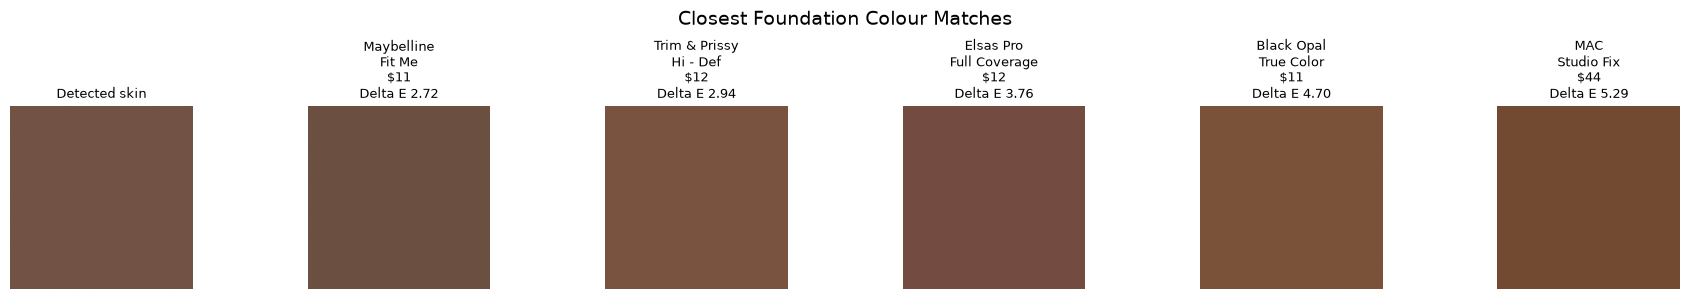


=== data/example_selfie_10.jpg ===


,brand,product,hex,price,color_distance
0,Revlon,ColorStay,A7745E,$18,5.58
1,Make Up For Ever,Ultra HD,B17862,$43,6.35
2,Elsas Pro,Full Coverage,906656,$12,7.32
3,Maybelline,Fit Me,9D7359,$11,7.33
4,RMK,RMK Liquid,C17663,$40,8.84


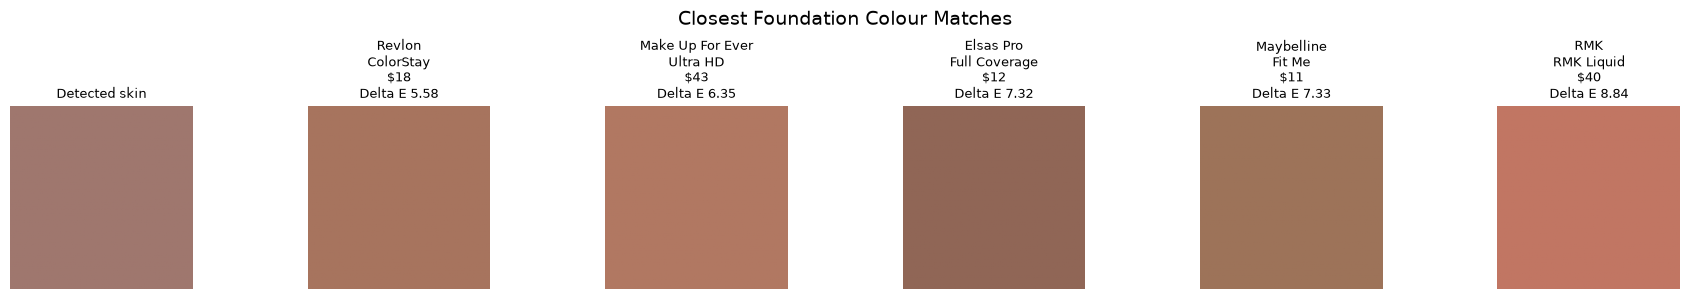

In [12]:
TOP_N = 5

for label, tone in zip(processed_labels, skin_tones, strict=True):
    recommendations = recommend_foundations(
        tone.lab,
        products,
        top_n=TOP_N,
    )

    display_columns = ["brand", "product", "hex"]
    format_spec = {"color_distance": "{:.2f}"}
    if "price" in recommendations.columns:
        display_columns.append("price")
        format_spec["price"] = lambda value: (
            "Unknown" if pd.isna(value) else f"${value:.0f}"
        )
    display_columns.append("color_distance")

    print(f"\n=== {label} ===")
    display(recommendations[display_columns].style.format(format_spec))
    plot_match_swatches(tone.rgb, recommendations)
    plt.show()


## 6. Interpretation

The first row is the closest digital colour in the catalogue, not
necessarily the best real-world product. Formula, oxidation, coverage,
undertone preferences, lighting, price, and availability are outside the
current dataset.

A production version should use calibrated images and professionally
labelled foundation matches rather than relying only on digital HEX values.
